Tolerance = 0.001
Jacobi iterations: 4
Gauss-Seidel iterations: 4



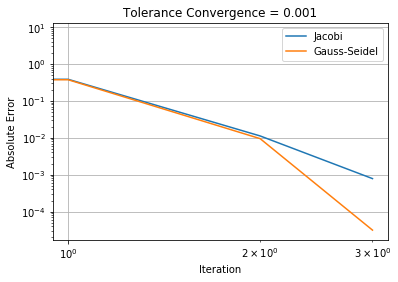

Tolerance = 1e-06
Jacobi iterations: 7
Gauss-Seidel iterations: 5



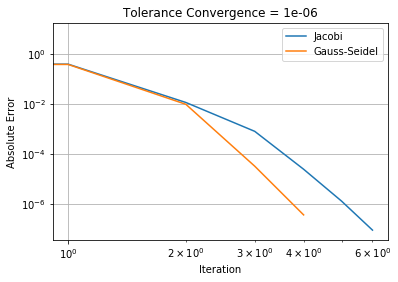

Tolerance = 1e-09
Jacobi iterations: 9
Gauss-Seidel iterations: 7



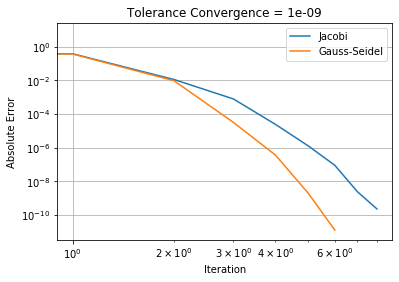

In [6]:
import numpy as np
import time
import matplotlib.pyplot as plt


def jacobi(A, b, x0, tol, max_iterations):
    
    n = len(b)
    x = x0.copy()
    errors = []
    
    start_time = time.time()
    
    for k in range(max_iterations):
        
        x_new = np.zeros(n)
        
        for i in range(n):
            
            total = 0
            
            for j in range(n):
                if j != i:
                    total = total + A[i][j] * x[j]
            
            x_new[i] = (b[i] - total) / A[i][i]
        
        error = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error)
        
        if error < tol:
            end_time = time.time()
            return x_new, k+1, end_time - start_time, errors
        
        x = x_new.copy()
    
    end_time = time.time()
    return x, max_iterations, end_time - start_time, errors


def gauss_seidel(A, b, x0, tol, max_iterations):
    
    n = len(b)
    x = x0.copy()
    errors = []
    
    start_time = time.time()
    
    for k in range(max_iterations):
        
        x_old = x.copy()
        
        for i in range(n):
            
            total1 = 0
            total2 = 0
            
            for j in range(i):
                total1 = total1 + A[i][j] * x[j]
                
            for j in range(i+1, n):
                total2 = total2 + A[i][j] * x_old[j]
            
            x[i] = (b[i] - total1 - total2) / A[i][i]
        
        error = np.linalg.norm(x - x_old, ord=np.inf)
        errors.append(error)
        
        if error < tol:
            end_time = time.time()
            return x, k+1, end_time - start_time, errors
    
    end_time = time.time()
    return x, max_iterations, end_time - start_time, errors


A = np.array([
    [3, -0.1, -0.2],
    [0.1, 7, -0.3],
    [0.3, -0.2, 10]
], dtype=float)

b = np.array([7.85, -19.3, 71.4], dtype=float)

x0 = np.zeros(len(b))
max_iterations = 10000

tolerances = [1e-3, 1e-6, 1e-9]

for tol in tolerances:
    
    result_j, iter_j, time_j, errors_j = jacobi(A, b, x0, tol, max_iterations)
    result_gs, iter_gs, time_gs, errors_gs = gauss_seidel(A, b, x0, tol, max_iterations)
    
    print("Tolerance =", tol)
    print("Jacobi iterations:", iter_j)
    print("Gauss-Seidel iterations:", iter_gs)
    print("")
    
    plt.figure()
    plt.loglog(errors_j)
    plt.loglog(errors_gs)
    plt.xlabel("Iteration")
    plt.ylabel("Absolute Error")
    plt.title("Tolerance Convergence = " + str(tol))
    plt.legend(["Jacobi", "Gauss-Seidel"])
    plt.grid(True)
    plt.show()

In [ ]:
# Had to ask AI for help with plotting because plt.plot() did not effectively compare the errors(loglog)
# As the tolerance decreases, the number of iterations requred for convergence increases since the method has to decrease the error
# A larger tolerance allows it to stop earlier using fewer iterations